In [45]:
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt

## Question 7
- we create the requested network.
- we add edges w.p. $\frac5N$
- we set the terminals $R = \set{1,...,N/2}$
- we set choose the edge weights unifomly from the set 1...5 : $\forall e \in E : w(e) \sim U\set{1...5}$

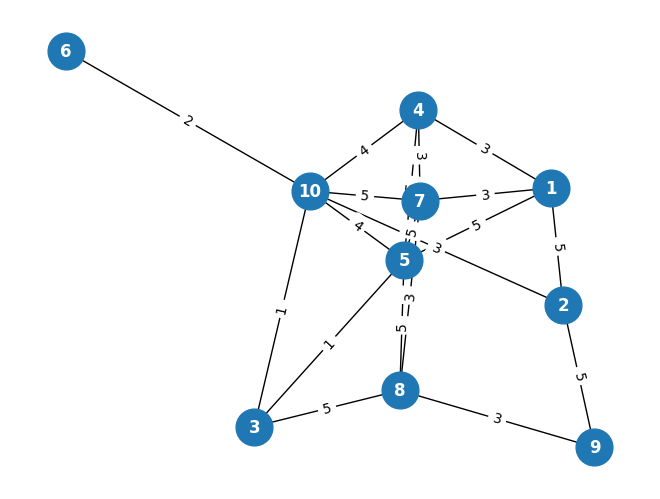

In [46]:
import networkx as nx
import matplotlib.pyplot as plt
import random

def generate_random_network(N, w_max=5):
    p = 5/N
    G = nx.erdos_renyi_graph(N, p)
    mapping = {i: i + 1 for i in range(N)}
    G = nx.relabel_nodes(G, mapping)
    for (u, v) in G.edges():
        G.edges[u, v]['weight'] = random.randint(1, w_max)
    return G

G = generate_random_network(10)

def draw_network(G):
    pos = nx.spring_layout(G)
    nx.draw(G, pos=pos, with_labels=True, font_weight='bold', node_color='#1f78b4', font_color='white', node_size=700)
    nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=nx.get_edge_attributes(G, 'weight'))
    plt.show()

draw_network(G)

### subsection a)
We need to calculate the following quantities for every value while iterating through all values of $N$:
- Check connectivity of the network $N = (G,w)$
- Calculate the Tree yielded by the $steiner2(G,w,R)$ algorithm
- Calculate the Tree yielded by the $steiner3(G,w,R)$ algorithm (in exercise 6...)
- Calculate the MST of the network $N = (G,w)$

#### steiner2
As shown in class, the $steiner2(G,w,R)$ algorithm is as follows :

steiner2(G,w,R):
- $d \gets Floyd_Warshall(G,w)$
- $\hat T \gets MST(G,w)$
- return $S(\hat T)$

Where: 
- $K_{R,d}$ is the complete graph of nodes of $G$ and 
where every edge between the Terminals $u,v\in R$ is in the graph 
if there exists a path from the terminals $u$ to $v$ in $G$ with total weight of $d_G(u,v)$ : $$(uv\in E_{R,d}) \land (w(uv) = d) \iff d_G(uv) = d $$
- $MST(G,w)$ can be either Prim or Kruskals algorithm for finding the MST of a graph.
- S(T) is the induced tree in G that is mapped from the tree in $K_{R,d}$

We are required to fullly recreated the $steiner2(G,w,R)$ algorithm which means that we need to write out the following algorithms:
- Floyd-Warshall
- Prim
- Initialization of $K_{R,d}$
- The mapping $S(T)$

#### Floyd-Warshall 
We write the code for the algorithm to return matrices of both :
- the minimum distance in the graph from u to v in the entry dist[u,v]
- the next node in the minimum distance path from u to v in the entry next_node[u,v]

In [47]:
def Floyd_Warshall(G):
    N = G.number_of_nodes()
    dist = np.full((N, N), np.inf)
    next_node = np.full((N, N), -1)

    for u in G.nodes():
        dist[u-1][u-1] = 0

    for (u, v, data) in G.edges(data=True):
        dist[u-1][v-1] = data['weight']
        next_node[u-1][v-1] = v

    for k in range(N):
        for i in range(N):
            for j in range(N):
                if dist[i][j] > dist[i][k] + dist[k][j]:
                    dist[i][j] = dist[i][k] + dist[k][j]
                    next_node[i][j] = next_node[i][k]

    return dist, next_node

#### Prim
We write the code for Prims algorithm as shown in class and return the edges of the MST of the graph. 

In [48]:
def Prim(G):
    """
    Constructs a directed spanning tree (arborescence) from the first node.
    Returns a NetworkX DiGraph to seamlessly interface with the next function.
    """
    T = nx.DiGraph()
    nodes = list(G.nodes())
    if not nodes:
        return T
        
    # Use dictionaries keyed by node names to prevent any indexing bugs
    visited = {n: False for n in nodes}
    min_edge = {n: (float('inf'), -1) for n in nodes}
    
    start_node = nodes[0]
    min_edge[start_node] = (0, -1)
    
    for _ in range(len(nodes)):
        # Find unvisited node with the smallest incoming edge weight
        u = -1
        min_weight = float('inf')
        for n in nodes:
            if not visited[n] and min_edge[n][0] < min_weight:
                min_weight = min_edge[n][0]
                u = n
                
        if u == -1: # Prevent infinite loop if the graph is disconnected
            break
            
        visited[u] = True
        
        # Add the physical edge to our tree (skip the dummy start edge)
        if min_edge[u][1] != -1:
            T.add_edge(min_edge[u][1], u, weight=min_edge[u][0])
            
        # Update neighbors using successors for directed graphs
        for v in G.successors(u):
            if not visited[v]:
                weight = G.edges[u, v]['weight']
                if weight < min_edge[v][0]:
                    min_edge[v] = (weight, u)
                    
    return T

#### $K_{R,d} : R = \set{1...\frac N2}$
After calculating the minimum distances of every pair of nodes we construct the complete graph of the terminals.

In [49]:
def K_R_d(G, d_matrix):
    """
    Constructs a complete directed graph on terminal nodes R.
    """
    N = G.number_of_nodes()
    
    terminal_count = N // 2
    R = list(range(1, terminal_count + 1))
    
    K_R = nx.DiGraph()
    K_R.add_nodes_from(R)
    
    for u in R:
        for v in R:
            if u != v:
                # FIXED: 1-based nodes to 0-based matrix mapping
                dist = d_matrix[u-1][v-1] 
                
                if dist != float('inf'):
                    K_R.add_edge(u, v, weight=dist)
                    
    return K_R

#### S(T) : mapping tree in $K_{R,d}$ back to an induced Tree of G

First we recostruct the path of minimum distance using the `next_node` matrix calculated previously from floyd-warshall

In [50]:
def reconstruct_path(next_node, u, v):
    """
    Rebuilds the physical path from u to v using the successor matrix.
    """
    if next_node[u-1][v-1] == -1:
        return []
        
    path = [u]
    current = u
    
    while current != v:
        current = next_node[current-1][v-1]
        path.append(current)
        
    return path

Now we can use this algorithm for mapping the mst we found in $K_{R,d}$ back to an induced tree on G.

In [51]:
def map_mst_to_original_graph(G, mst, next_node_matrix):
    H = nx.DiGraph()
    
    # mst is now a DiGraph, so .edges() works perfectly
    for u, v in mst.edges():
        physical_path = reconstruct_path(next_node_matrix, u, v)
        
        for i in range(len(physical_path) - 1):
            node_a = physical_path[i]
            node_b = physical_path[i+1]
            
            if not H.has_edge(node_a, node_b):
                original_weight = G[node_a][node_b]['weight']
                H.add_edge(node_a, node_b, weight=original_weight)
                
    return H

#### Final $steiner2$ algorithm
Now we can use all of the algorithms we wrote to build the full $steiner2$ algorithm

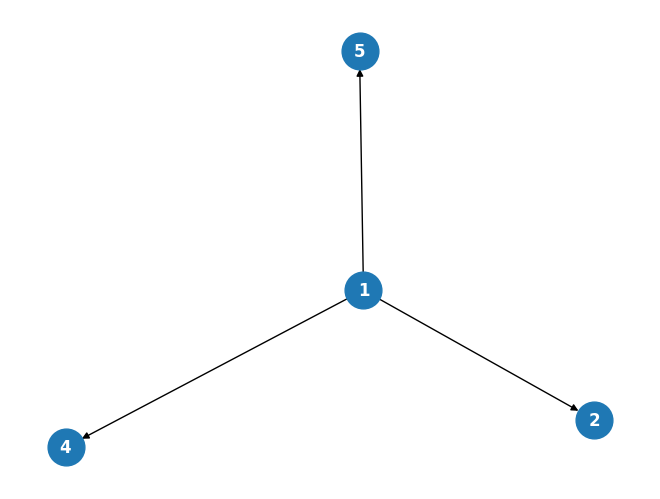

In [52]:
def steiner2(G):
    d_matrix, next_node_matrix = Floyd_Warshall(G)
    K_R = K_R_d(G, d_matrix)
    T = Prim(K_R)
    H = map_mst_to_original_graph(G, T, next_node_matrix)
    return H

H = steiner2(G)
nx.draw(H, with_labels=True, font_weight='bold', node_color='#1f78b4', font_color='white', node_size=700)

#### Sanity checks 
We test a few edge cases to see that the code does not crash and does return a result that matches theory.

We add an auxiliary function for displaying the results of the edge cases nicely.

In [63]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_steiner_results(G, H):
    """
    Plots the original graph G and the resulting Steiner Tree H side-by-side.
    Terminals are highlighted in orange, regular nodes in blue.
    """
    N = G.number_of_nodes()
    terminal_count = N // 2
    terminals = list(range(1, terminal_count + 1))
    non_terminals = [node for node in G.nodes() if node not in terminals]

    pos = nx.spring_layout(G, seed=42)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

    ax1.set_title("Original Graph (G)", fontsize=18, fontweight='bold')
    
    nx.draw_networkx_nodes(G, pos, nodelist=non_terminals, node_color='#1f78b4',node_size=700, ax=ax1)
    nx.draw_networkx_nodes(G, pos, nodelist=terminals, node_color='#ff7f0e',node_size=700, ax=ax1)
    
    nx.draw_networkx_edges(G, pos, ax=ax1, arrows=True, arrowsize=15, alpha=0.4)
    nx.draw_networkx_labels(G, pos, font_color='white', font_weight='bold', ax=ax1)
    
    edge_weights_G = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_weights_G, ax=ax1)
    ax1.axis('off')

    ax2.set_title("Mapped Steiner Tree (H)", fontsize=18, fontweight='bold')
    
    nx.draw_networkx_edges(G, pos, ax=ax2, arrows=False, alpha=0.1, edge_color='gray')
    nx.draw_networkx_nodes(G, pos, ax=ax2, node_color='lightgray', node_size=700, alpha=0.3)

    H_nodes = list(H.nodes())
    H_terminals = [n for n in H_nodes if n in terminals]
    H_non_terminals = [n for n in H_nodes if n not in terminals]

    nx.draw_networkx_nodes(H, pos, nodelist=H_non_terminals, node_color='#1f78b4', node_size=700, ax=ax2)
    nx.draw_networkx_nodes(H, pos, nodelist=H_terminals, node_color='#ff7f0e', node_size=700, ax=ax2)
    
    nx.draw_networkx_edges(H, pos, ax=ax2, arrows=True, arrowsize=20, edge_color='black', width=2.5)
    nx.draw_networkx_labels(H, pos, font_color='white', font_weight='bold', ax=ax2)

    edge_weights_H = nx.get_edge_attributes(H, 'weight')
    nx.draw_networkx_edge_labels(H, pos, edge_labels=edge_weights_H, font_weight='bold', ax=ax2)
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

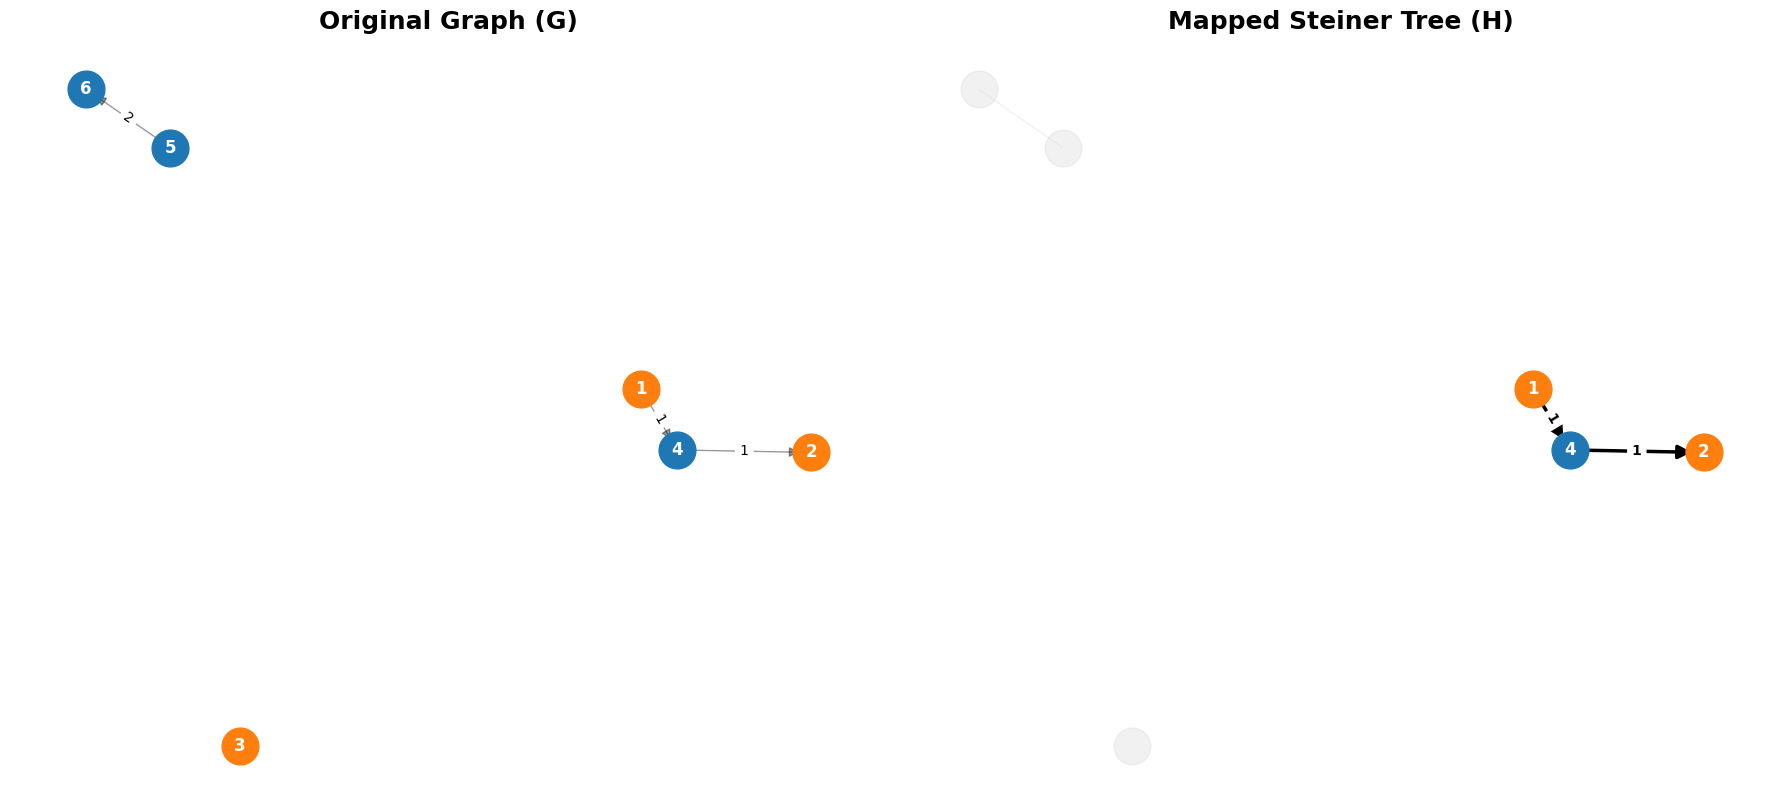

In [64]:
def test_isolated_terminal():
    G = nx.DiGraph()
    G.add_nodes_from(range(1, 7)) # N=6, Terminals are 1, 2, 3
    
    # Node 1 can reach Node 2 efficiently
    G.add_weighted_edges_from([(1, 4, 1), (4, 2, 1)])
    
    # Node 3 is completely isolated (no incoming or outgoing edges)
    # Node 5 and 6 are just background nodes
    G.add_weighted_edges_from([(5, 6, 2)]) 
    
    return G

G_1 = test_isolated_terminal()
steiner_tree_1 = steiner2(G_1)
plot_steiner_results(G_1, steiner_tree_1)

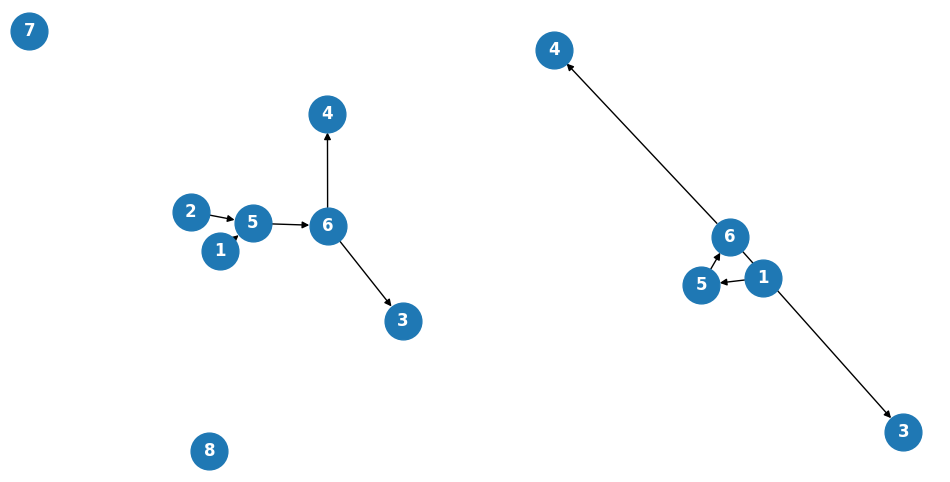

In [62]:
def test_shared_highway():
    G = nx.DiGraph()
    G.add_nodes_from(range(1, 9)) # N=8, Terminals are 1, 2, 3, 4
    
    # Nodes 1 and 2 both funnel into node 5
    G.add_weighted_edges_from([(1, 5, 1), (2, 5, 1)])
    
    # The "Shared Highway" bottleneck
    G.add_weighted_edges_from([(5, 6, 1)])
    
    # Node 6 splits out to destinations 3 and 4
    G.add_weighted_edges_from([(6, 3, 1), (6, 4, 1)])
    
    return G

G_2 = test_shared_highway()
steiner_tree_2 = steiner2(G_2)
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
nx.draw(G_2, with_labels=True, font_weight='bold', node_color='#1f78b4', font_color='white', node_size=700, ax=axs[0])
nx.draw(steiner_tree_2, with_labels=True, font_weight='bold', node_color='#1f78b4', font_color='white', node_size=700, ax=axs[1])